In [1]:
import sys
sys.path.append("PATH TO src folder")
sys.path.append("PATH TO DIRECTORY CONTAINING THIS NOTEBOOK")

In [2]:
%load_ext autoreload
%autoreload 2

#Setting Up and Importing the Necessary Packages/Libraries
##Package for reading in Bruker OPUS type files
from brukeropusreader import read_file
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline
import pathlib

#Local Functions
from prospecpy.cut_range import cut_range_subtract_prospecpy_objects
from prospecpy.second_deriv import  second_deriv_prospecpy_objects
from prospecpy.baseline import baseline_correction_prospecpy_objects
from prospecpy.peak_fit import gaussian_fit_prospecpy_objects, lorentzian_fit_prospecpy_objects
from prospecpy.io import import_run_data
from prospecpy.interact import interact


# Importing spectra data and water vapor data

# Creating Folders for Data and Plots

Within the data folder, create three more folders, water_vapor, output_plots, and one with a name describing this run or experiment.


In [3]:
#Paths to Local Data
path_to_water_vapor_data = pathlib.Path("../data/opus_files/water_vapor")
path_to_output_plots_= pathlib.Path("../data/output_plots/")
# path_to_FILL_IN_data = pathlib.Path("../../data/opus_files/FILL_IN") 
path_to_FILL_IN_data = pathlib.Path("../data/opus_files/pH6")

### Workflow Overview
The function called below `import_run_data`, creates a dict full of ProSpecPy objects, with empty attributes to be completed in the each of the following steps. For each of these steps, the function will write a corresponding plot labeled with the name of the sample to a folder describing the sample and step, within the `output_plots` directory specified above.


In [4]:
FILL_IN_raw_data = import_run_data(
    path_to_FILL_IN_data,
    input_type="raw spectra",
    output_folder="../output_plots/"
)

wv_data = import_run_data(path_to_water_vapor_data)

# Subtracting water vapor from raw spectra

Make sure to define the desired wave numbers for `range_start` and `range_end` which best fit your sample run.

In [5]:
#Initializing dict of post water vapor subtraction spectra
## cut_range_subtract_prospecpy_objects(FILL_IN_raw_data, wv_data, range_start = 2150, range_end = 1850, showplots=False, verbose= True)
#pD6_raw_data[].cut_subtracted_data

In [6]:
#Initializing dict of post water vapor subtraction spectra
cut_range_subtract_prospecpy_objects(FILL_IN_raw_data, wv_data, range_start = 2150, range_end = 1850, showplots=False, verbose= True)
#pH6_raw_data[].cut_subtracted_data

Plot saved to ../output_plots//pH6/011a as iso Hyd2 dark titration 0 mV.0022/cut_range_subtracted_spectra
Atmospheric fit parameters saved to ../output_plots//pH6/011a as iso Hyd2 dark titration 0 mV.0022/cut_atmfitparameters.csv
Cut subtracted data saved to ../output_plots//pH6/011a as iso Hyd2 dark titration 0 mV.0022/cut_subtracted_data.csv
Plot saved to ../output_plots//pH6/011b as iso Hyd2 dark titration -50 mV.0004/cut_range_subtracted_spectra
Atmospheric fit parameters saved to ../output_plots//pH6/011b as iso Hyd2 dark titration -50 mV.0004/cut_atmfitparameters.csv
Cut subtracted data saved to ../output_plots//pH6/011b as iso Hyd2 dark titration -50 mV.0004/cut_subtracted_data.csv
Plot saved to ../output_plots//pH6/011c as iso Hyd2 dark titration -100 mV.0003/cut_range_subtracted_spectra
Atmospheric fit parameters saved to ../output_plots//pH6/011c as iso Hyd2 dark titration -100 mV.0003/cut_atmfitparameters.csv
Cut subtracted data saved to ../output_plots//pH6/011c as iso Hyd2

## Get the second derivatives

In [7]:
second_deriv_prospecpy_objects(FILL_IN_raw_data, show_plots=False, verbose = True)

Plot saved to ../output_plots//pH6/011a as iso Hyd2 dark titration 0 mV.0022/subtracted_spectra
Plot saved to ../output_plots//pH6/011a as iso Hyd2 dark titration 0 mV.0022/second_derivative_fig
Second derivative csv data saved to ../output_plots//pH6/011a as iso Hyd2 dark titration 0 mV.0022/second_derivative_data.csv


Plot saved to ../output_plots//pH6/011b as iso Hyd2 dark titration -50 mV.0004/subtracted_spectra
Plot saved to ../output_plots//pH6/011b as iso Hyd2 dark titration -50 mV.0004/second_derivative_fig
Second derivative csv data saved to ../output_plots//pH6/011b as iso Hyd2 dark titration -50 mV.0004/second_derivative_data.csv
Plot saved to ../output_plots//pH6/011c as iso Hyd2 dark titration -100 mV.0003/subtracted_spectra
Plot saved to ../output_plots//pH6/011c as iso Hyd2 dark titration -100 mV.0003/second_derivative_fig
Second derivative csv data saved to ../output_plots//pH6/011c as iso Hyd2 dark titration -100 mV.0003/second_derivative_data.csv
Plot saved to ../output_plots//pH6/011d as iso Hyd2 dark titration -1050mV.0007/subtracted_spectra
Plot saved to ../output_plots//pH6/011d as iso Hyd2 dark titration -1050mV.0007/second_derivative_fig
Second derivative csv data saved to ../output_plots//pH6/011d as iso Hyd2 dark titration -1050mV.0007/second_derivative_data.csv
Plot saved to

## Using a user interface please select the appropriate number of peaks using the threshold variable and number of anchor points using adjustment factor variable

Be sure to do this for each sample in the run, otherwise the notebook will give you some warnings.

In [8]:
interact(FILL_IN_raw_data,0.4,1.8)

ToggleButtons(description='Step 1. File selection:', options=('011a as iso Hyd2 dark titration 0 mV.0022', '01…

Output()

BoundedFloatText(value=0.4, description='Threshold for peak selection(0.01 to 1 in 0.01 steps):', layout=Layou…

BoundedFloatText(value=1.8, description='adj for anchor point selection(0.01 to 5 in 0.01 steps):', layout=Lay…

Button(description='Save', style=ButtonStyle())

# Baseline correction and cruve fit for an example spectra workflow:

## Fit baseline spline through these anchor points to be used for baseline correction of raw spectra

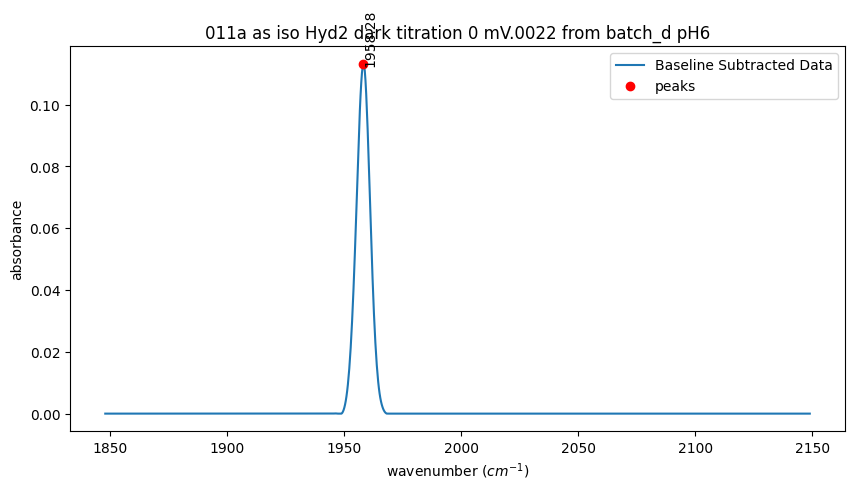

Plot saved to ../output_plots//pH6/011a as iso Hyd2 dark titration 0 mV.0022/baseline_subtracted_spectra
Baseline corrected csv data saved to ../output_plots//pH6/011a as iso Hyd2 dark titration 0 mV.0022/baseline_corrected_data.csv
Baseline corrected peak info saved to ../output_plots//pH6/011a as iso Hyd2 dark titration 0 mV.0022/baseline_corrected_peak_info.csv


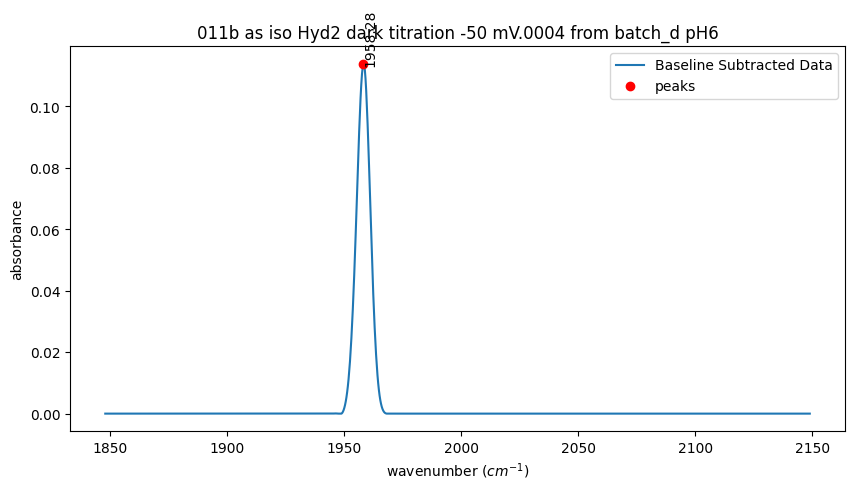

Plot saved to ../output_plots//pH6/011b as iso Hyd2 dark titration -50 mV.0004/baseline_subtracted_spectra
Baseline corrected csv data saved to ../output_plots//pH6/011b as iso Hyd2 dark titration -50 mV.0004/baseline_corrected_data.csv
Baseline corrected peak info saved to ../output_plots//pH6/011b as iso Hyd2 dark titration -50 mV.0004/baseline_corrected_peak_info.csv


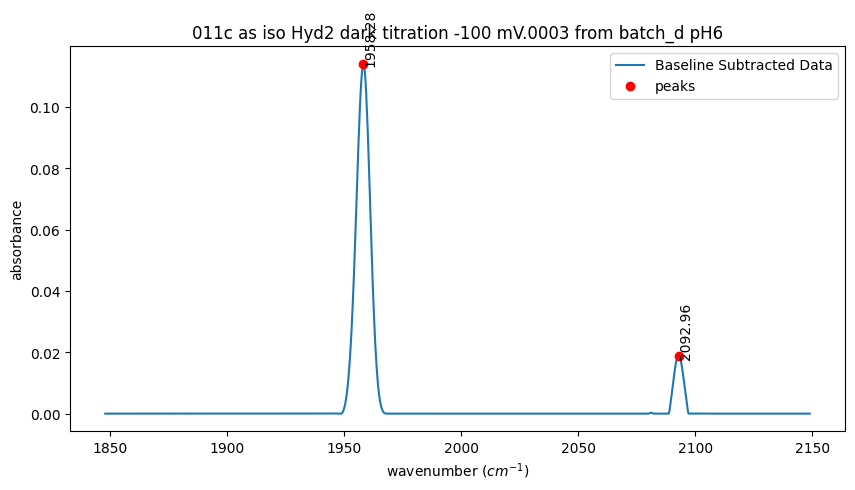

Plot saved to ../output_plots//pH6/011c as iso Hyd2 dark titration -100 mV.0003/baseline_subtracted_spectra
Baseline corrected csv data saved to ../output_plots//pH6/011c as iso Hyd2 dark titration -100 mV.0003/baseline_corrected_data.csv
Baseline corrected peak info saved to ../output_plots//pH6/011c as iso Hyd2 dark titration -100 mV.0003/baseline_corrected_peak_info.csv


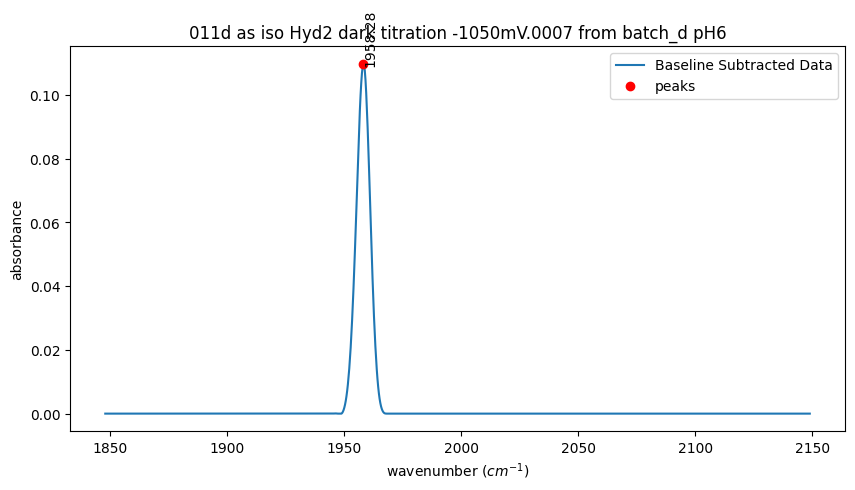

Plot saved to ../output_plots//pH6/011d as iso Hyd2 dark titration -1050mV.0007/baseline_subtracted_spectra
Baseline corrected csv data saved to ../output_plots//pH6/011d as iso Hyd2 dark titration -1050mV.0007/baseline_corrected_data.csv
Baseline corrected peak info saved to ../output_plots//pH6/011d as iso Hyd2 dark titration -1050mV.0007/baseline_corrected_peak_info.csv


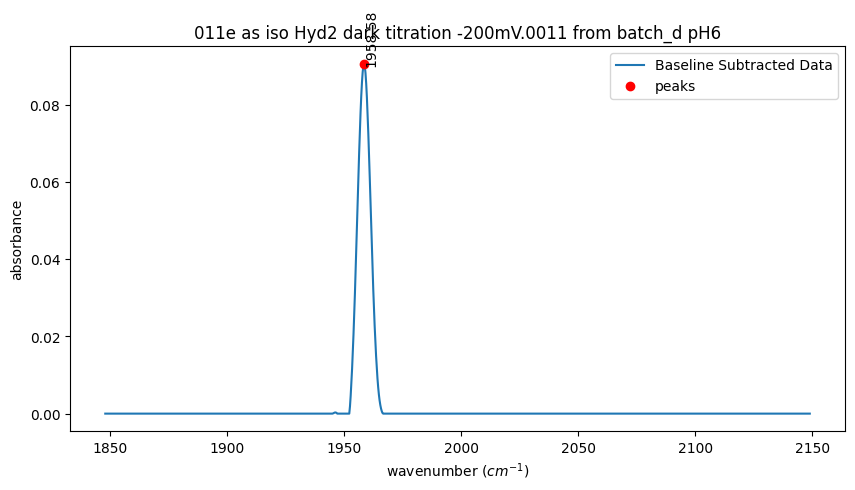

Plot saved to ../output_plots//pH6/011e as iso Hyd2 dark titration -200mV.0011/baseline_subtracted_spectra
Baseline corrected csv data saved to ../output_plots//pH6/011e as iso Hyd2 dark titration -200mV.0011/baseline_corrected_data.csv
Baseline corrected peak info saved to ../output_plots//pH6/011e as iso Hyd2 dark titration -200mV.0011/baseline_corrected_peak_info.csv


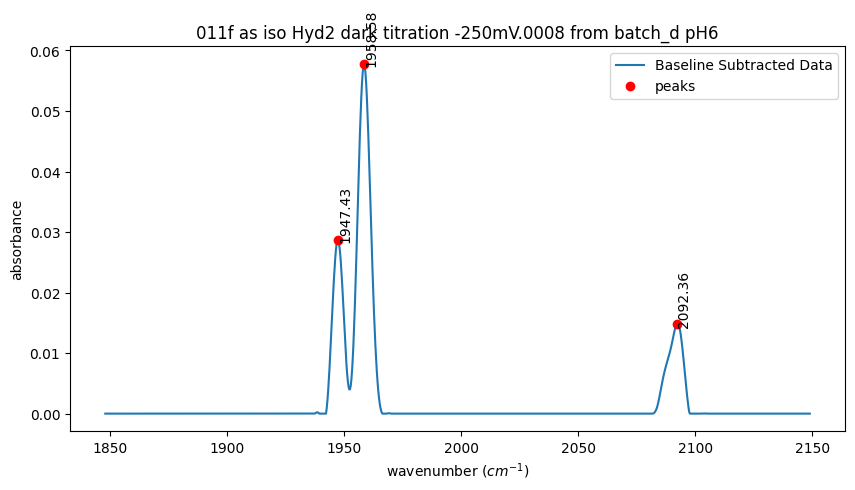

Plot saved to ../output_plots//pH6/011f as iso Hyd2 dark titration -250mV.0008/baseline_subtracted_spectra
Baseline corrected csv data saved to ../output_plots//pH6/011f as iso Hyd2 dark titration -250mV.0008/baseline_corrected_data.csv
Baseline corrected peak info saved to ../output_plots//pH6/011f as iso Hyd2 dark titration -250mV.0008/baseline_corrected_peak_info.csv


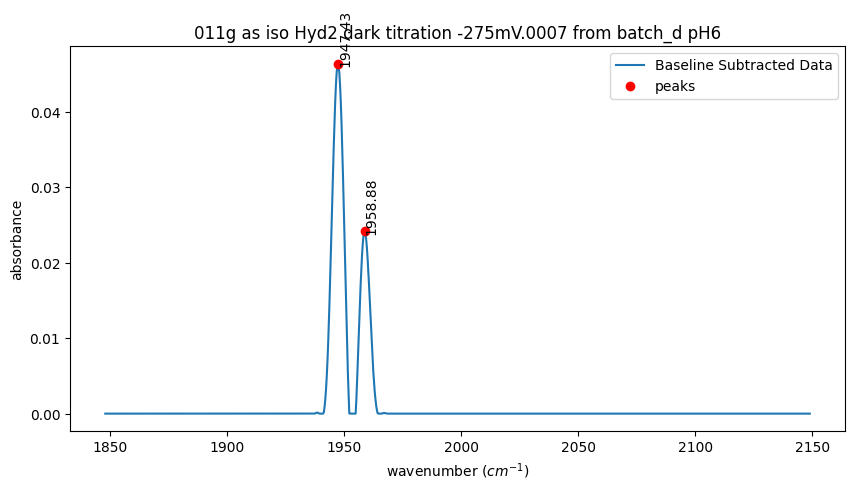

Plot saved to ../output_plots//pH6/011g as iso Hyd2 dark titration -275mV.0007/baseline_subtracted_spectra
Baseline corrected csv data saved to ../output_plots//pH6/011g as iso Hyd2 dark titration -275mV.0007/baseline_corrected_data.csv
Baseline corrected peak info saved to ../output_plots//pH6/011g as iso Hyd2 dark titration -275mV.0007/baseline_corrected_peak_info.csv


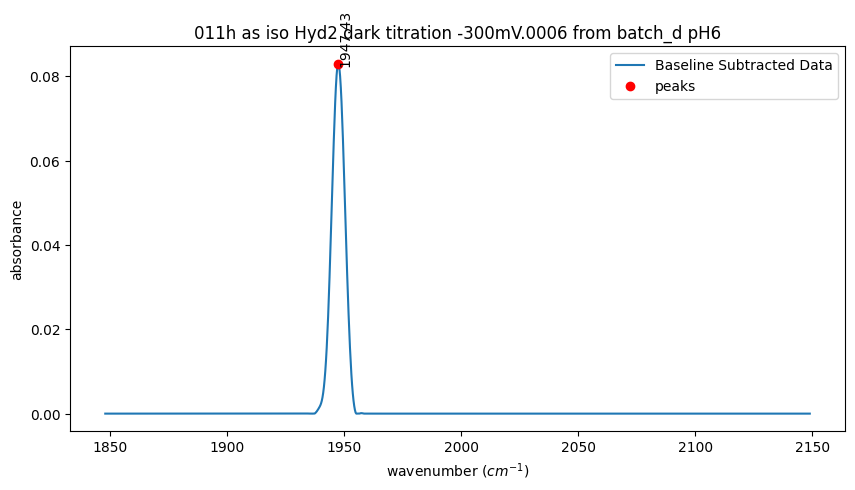

Plot saved to ../output_plots//pH6/011h as iso Hyd2 dark titration -300mV.0006/baseline_subtracted_spectra
Baseline corrected csv data saved to ../output_plots//pH6/011h as iso Hyd2 dark titration -300mV.0006/baseline_corrected_data.csv
Baseline corrected peak info saved to ../output_plots//pH6/011h as iso Hyd2 dark titration -300mV.0006/baseline_corrected_peak_info.csv


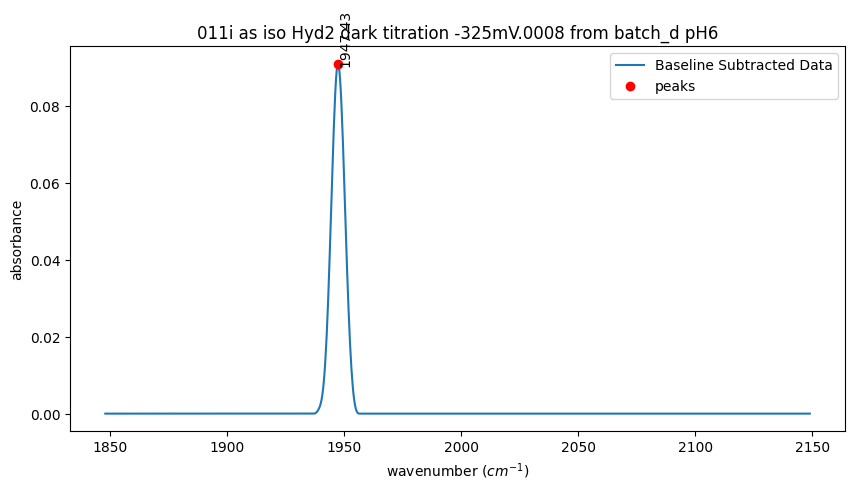

Plot saved to ../output_plots//pH6/011i as iso Hyd2 dark titration -325mV.0008/baseline_subtracted_spectra
Baseline corrected csv data saved to ../output_plots//pH6/011i as iso Hyd2 dark titration -325mV.0008/baseline_corrected_data.csv
Baseline corrected peak info saved to ../output_plots//pH6/011i as iso Hyd2 dark titration -325mV.0008/baseline_corrected_peak_info.csv


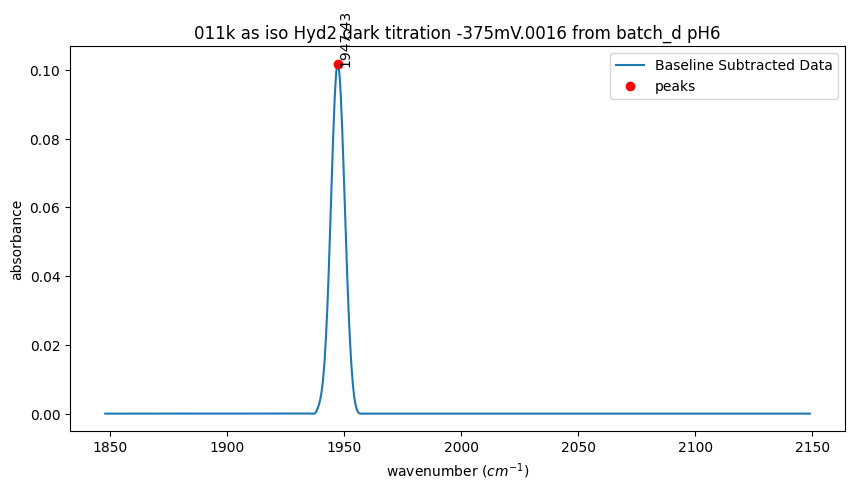

Plot saved to ../output_plots//pH6/011k as iso Hyd2 dark titration -375mV.0016/baseline_subtracted_spectra
Baseline corrected csv data saved to ../output_plots//pH6/011k as iso Hyd2 dark titration -375mV.0016/baseline_corrected_data.csv
Baseline corrected peak info saved to ../output_plots//pH6/011k as iso Hyd2 dark titration -375mV.0016/baseline_corrected_peak_info.csv


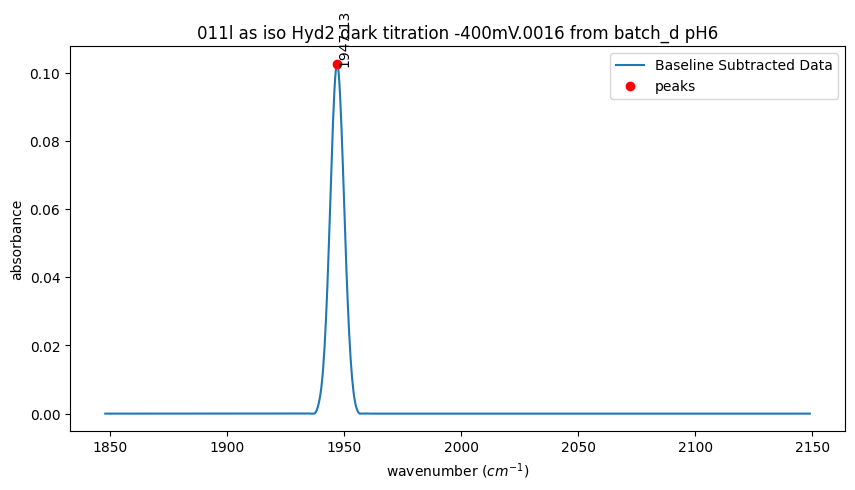

Plot saved to ../output_plots//pH6/011l as iso Hyd2 dark titration -400mV.0016/baseline_subtracted_spectra
Baseline corrected csv data saved to ../output_plots//pH6/011l as iso Hyd2 dark titration -400mV.0016/baseline_corrected_data.csv
Baseline corrected peak info saved to ../output_plots//pH6/011l as iso Hyd2 dark titration -400mV.0016/baseline_corrected_peak_info.csv


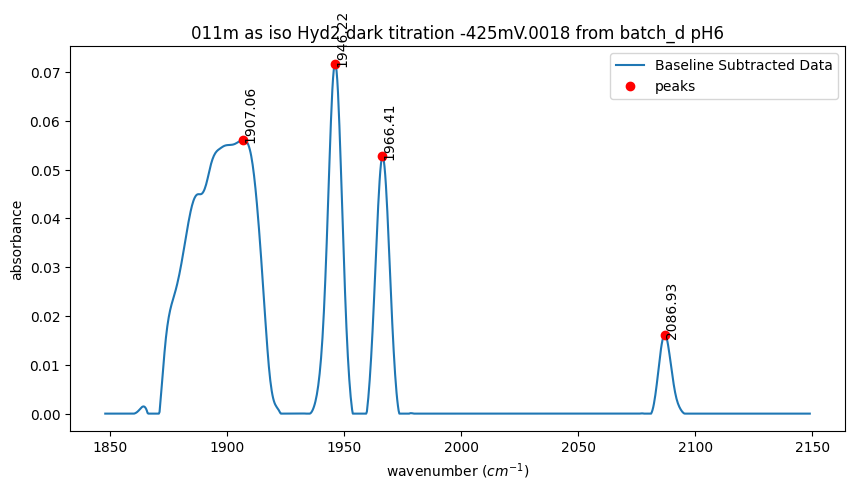

Plot saved to ../output_plots//pH6/011m as iso Hyd2 dark titration -425mV.0018/baseline_subtracted_spectra
Baseline corrected csv data saved to ../output_plots//pH6/011m as iso Hyd2 dark titration -425mV.0018/baseline_corrected_data.csv
Baseline corrected peak info saved to ../output_plots//pH6/011m as iso Hyd2 dark titration -425mV.0018/baseline_corrected_peak_info.csv


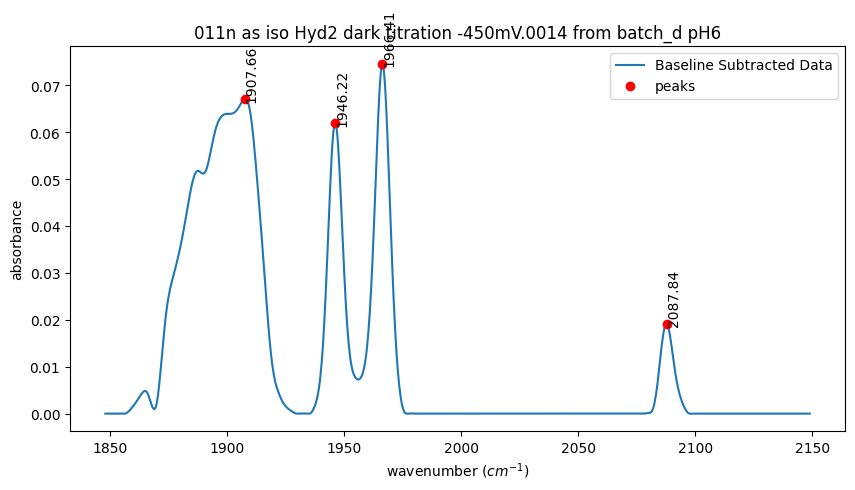

Plot saved to ../output_plots//pH6/011n as iso Hyd2 dark titration -450mV.0014/baseline_subtracted_spectra
Baseline corrected csv data saved to ../output_plots//pH6/011n as iso Hyd2 dark titration -450mV.0014/baseline_corrected_data.csv
Baseline corrected peak info saved to ../output_plots//pH6/011n as iso Hyd2 dark titration -450mV.0014/baseline_corrected_peak_info.csv


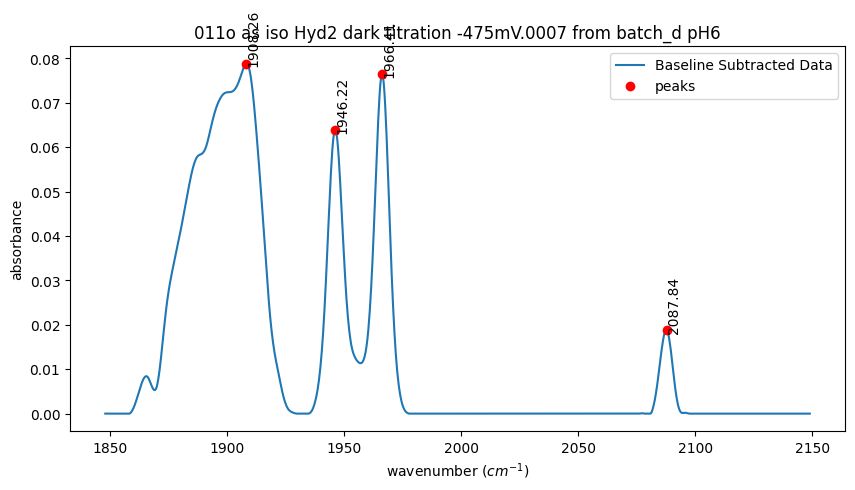

Plot saved to ../output_plots//pH6/011o as iso Hyd2 dark titration -475mV.0007/baseline_subtracted_spectra
Baseline corrected csv data saved to ../output_plots//pH6/011o as iso Hyd2 dark titration -475mV.0007/baseline_corrected_data.csv
Baseline corrected peak info saved to ../output_plots//pH6/011o as iso Hyd2 dark titration -475mV.0007/baseline_corrected_peak_info.csv


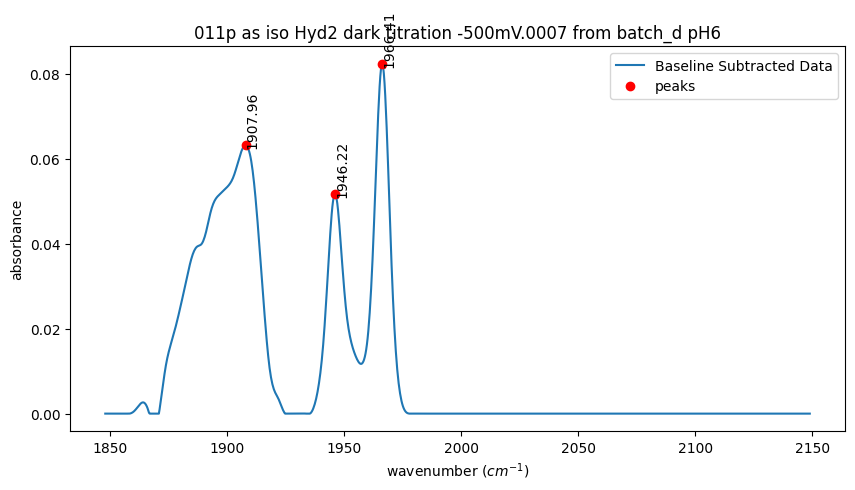

Plot saved to ../output_plots//pH6/011p as iso Hyd2 dark titration -500mV.0007/baseline_subtracted_spectra
Baseline corrected csv data saved to ../output_plots//pH6/011p as iso Hyd2 dark titration -500mV.0007/baseline_corrected_data.csv
Baseline corrected peak info saved to ../output_plots//pH6/011p as iso Hyd2 dark titration -500mV.0007/baseline_corrected_peak_info.csv


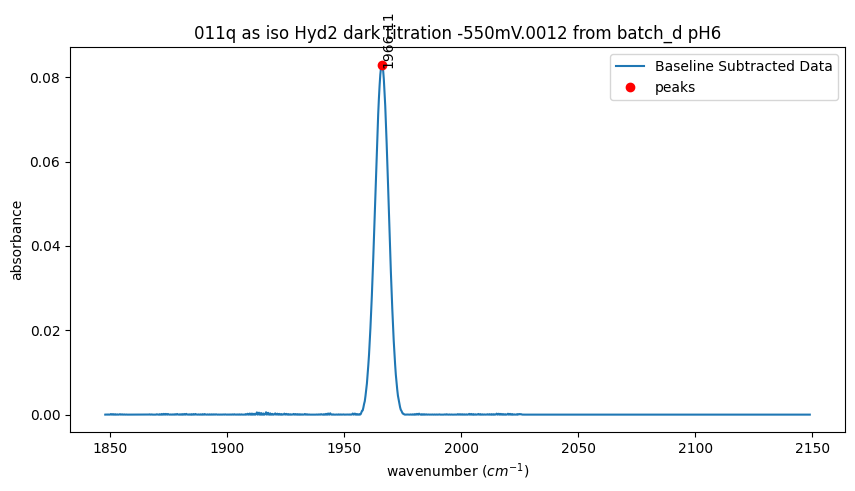

Plot saved to ../output_plots//pH6/011q as iso Hyd2 dark titration -550mV.0012/baseline_subtracted_spectra
Baseline corrected csv data saved to ../output_plots//pH6/011q as iso Hyd2 dark titration -550mV.0012/baseline_corrected_data.csv
Baseline corrected peak info saved to ../output_plots//pH6/011q as iso Hyd2 dark titration -550mV.0012/baseline_corrected_peak_info.csv


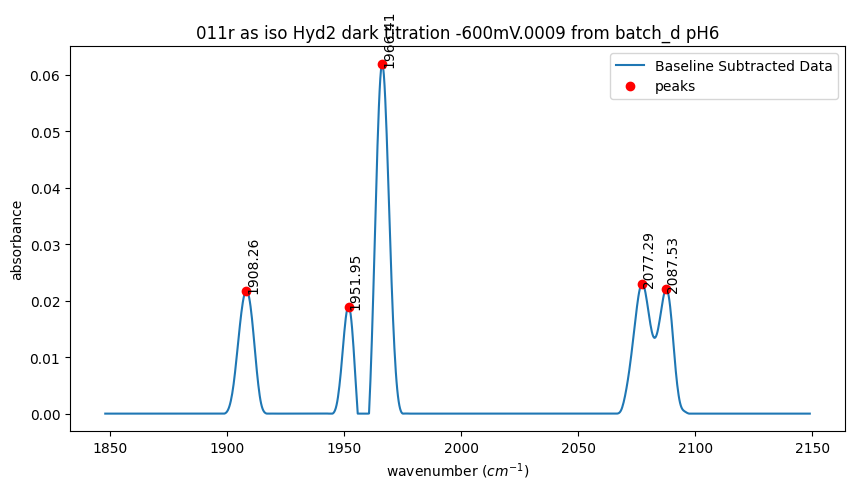

Plot saved to ../output_plots//pH6/011r as iso Hyd2 dark titration -600mV.0009/baseline_subtracted_spectra
Baseline corrected csv data saved to ../output_plots//pH6/011r as iso Hyd2 dark titration -600mV.0009/baseline_corrected_data.csv
Baseline corrected peak info saved to ../output_plots//pH6/011r as iso Hyd2 dark titration -600mV.0009/baseline_corrected_peak_info.csv


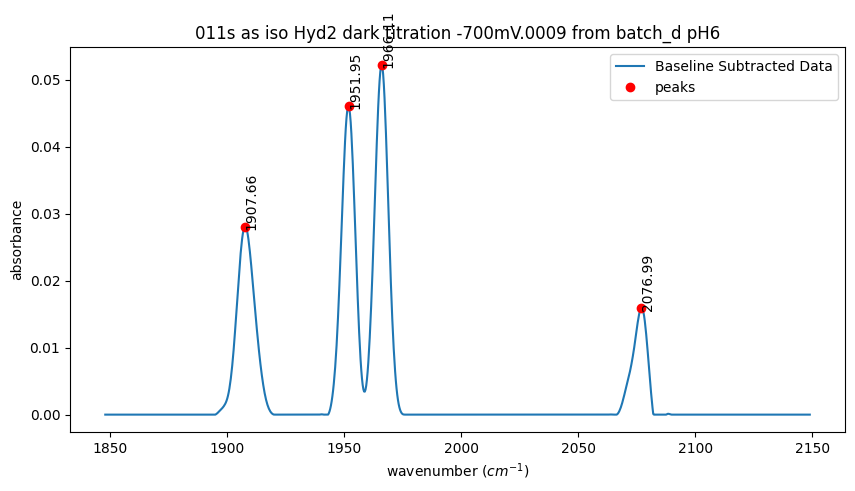

Plot saved to ../output_plots//pH6/011s as iso Hyd2 dark titration -700mV.0009/baseline_subtracted_spectra
Baseline corrected csv data saved to ../output_plots//pH6/011s as iso Hyd2 dark titration -700mV.0009/baseline_corrected_data.csv
Baseline corrected peak info saved to ../output_plots//pH6/011s as iso Hyd2 dark titration -700mV.0009/baseline_corrected_peak_info.csv


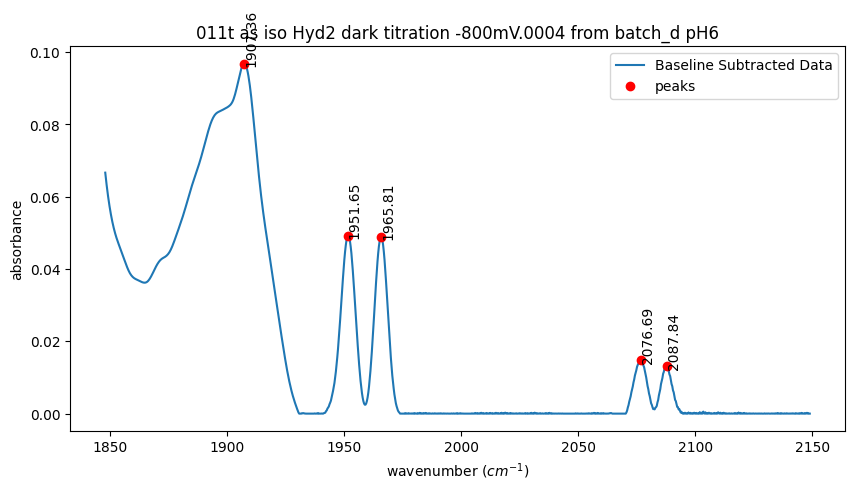

Plot saved to ../output_plots//pH6/011t as iso Hyd2 dark titration -800mV.0004/baseline_subtracted_spectra
Baseline corrected csv data saved to ../output_plots//pH6/011t as iso Hyd2 dark titration -800mV.0004/baseline_corrected_data.csv
Baseline corrected peak info saved to ../output_plots//pH6/011t as iso Hyd2 dark titration -800mV.0004/baseline_corrected_peak_info.csv


In [11]:
baseline_correction_prospecpy_objects(FILL_IN_raw_data, showplot = True, save = True, verbose = True)

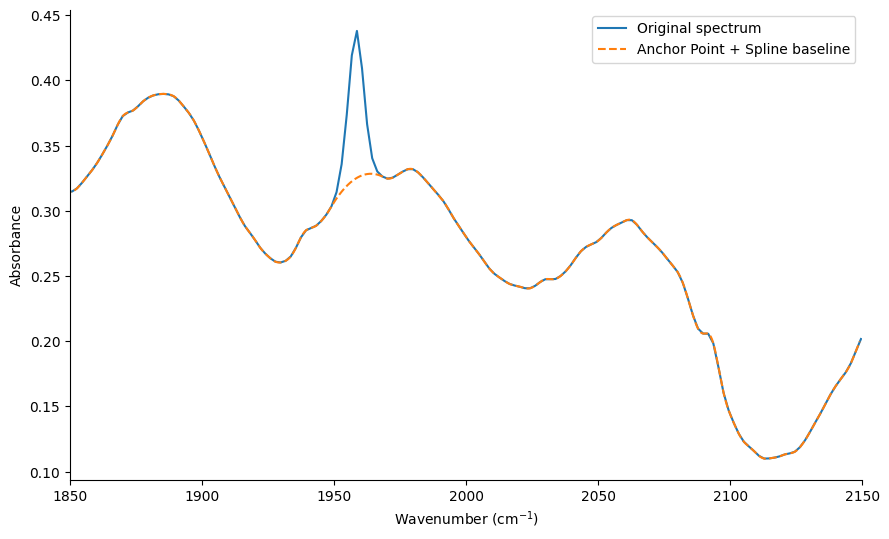

Saved PNG: ../paper_figures/anchor_point_spline_baseline_estimation_011a.png
Saved PDF: ../paper_figures/anchor_point_spline_baseline_estimation_011a.pdf


In [12]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


# =========================================================
# 1. Select the representative spectrum
# =========================================================
sample = next(
    obj for obj in FILL_IN_raw_data
    if str(obj.sample_name).startswith("011a")
)

# Check that the Anchor Point + Spline baseline has been generated.
if sample.get_baseline_curve() is None:
    raise ValueError(
        "The baseline curve has not been generated. "
        "Run the interactive anchor-point selection and baseline-correction "
        "cells before running this cell."
    )


# =========================================================
# 2. Obtain the original preprocessed spectrum
#    and the estimated spline baseline
# =========================================================
original_wavenumber = np.asarray(
    sample.get_subtracted_spectra_wavenumber(),
    dtype=float,
)

original_absorbance = np.asarray(
    sample.get_subtracted_spectra_absorbance(),
    dtype=float,
)

baseline_curve = sample.get_baseline_curve()

baseline_wavenumber = np.asarray(
    baseline_curve["wavenumber"],
    dtype=float,
)

baseline_absorbance = np.asarray(
    baseline_curve["absorbance"],
    dtype=float,
)


# Sort both curves by increasing wavenumber for plotting.
original_order = np.argsort(original_wavenumber)
baseline_order = np.argsort(baseline_wavenumber)

original_wavenumber = original_wavenumber[original_order]
original_absorbance = original_absorbance[original_order]

baseline_wavenumber = baseline_wavenumber[baseline_order]
baseline_absorbance = baseline_absorbance[baseline_order]


# =========================================================
# 3. Plot in the same style as the asPLS and arPLS figures
# =========================================================
fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(
    original_wavenumber,
    original_absorbance,
    linewidth=1.5,
    label="Original spectrum",
)

ax.plot(
    baseline_wavenumber,
    baseline_absorbance,
    linestyle="--",
    linewidth=1.5,
    label="Anchor Point + Spline baseline",
)

ax.set_xlabel(r"Wavenumber (cm$^{-1}$)")
ax.set_ylabel("Absorbance")
ax.set_xlim(1850, 2150)

ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()


# =========================================================
# 4. Save the figure
# =========================================================
output_folder = Path("../paper_figures")
output_folder.mkdir(parents=True, exist_ok=True)

output_png = (
    output_folder
    / "anchor_point_spline_baseline_estimation_011a.png"
)

output_pdf = (
    output_folder
    / "anchor_point_spline_baseline_estimation_011a.pdf"
)

fig.savefig(
    output_png,
    dpi=600,
    bbox_inches="tight",
)

fig.savefig(
    output_pdf,
    bbox_inches="tight",
)

plt.show()

print(f"Saved PNG: {output_png}")
print(f"Saved PDF: {output_pdf}")